# Patch comparison

## SNR time evolution

In [ ]:
import pickle, glob
import matplotlib.pyplot as plt

In [ ]:
region_files = glob.glob("*_comparison.pkl")
regions = {r["name"]: r for r in [pickle.load(open(f,"rb")) for f in region_files]}

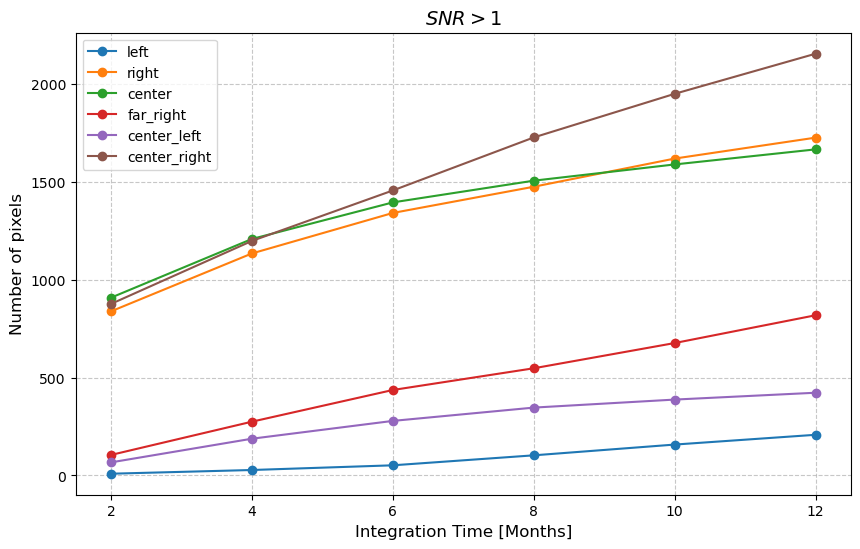

In [3]:
plt.figure(figsize=(10, 6))
months = [2, 4, 6, 8, 10, 12]
for name, r in regions.items():
    plt.plot(months, r['n_pix'][1], marker='o', label=name)

plt.title('$SNR > 1$', fontsize=14)
plt.xlabel('Integration Time [Months]', fontsize=12)
plt.ylabel('Number of pixels', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(frameon=True)

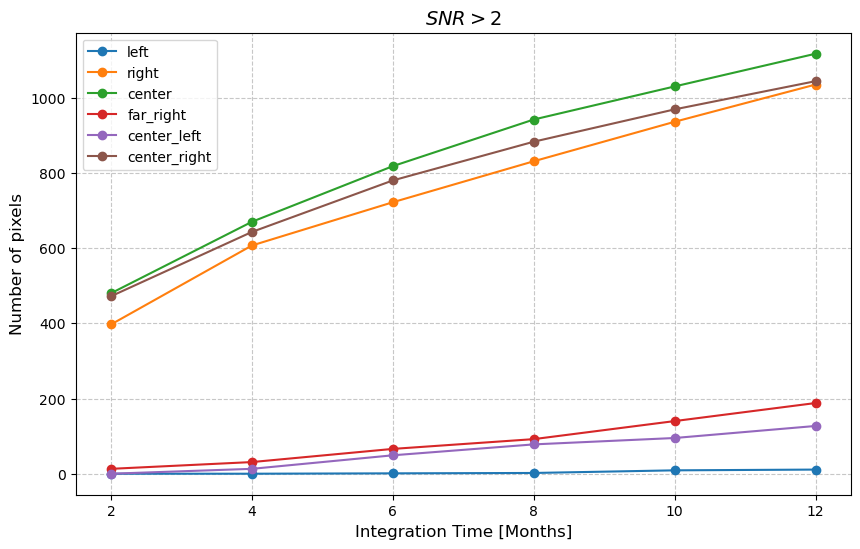

In [5]:
plt.figure(figsize=(10, 6))
months = [2, 4, 6, 8, 10, 12]
for name, r in regions.items():
    plt.plot(months, r['n_pix'][2], marker='o', label=name)

# Formattazione del grafico scientifico
plt.title('$SNR > 2$', fontsize=14)
plt.xlabel('Integration Time [Months]', fontsize=12)
plt.ylabel('Number of pixels', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(frameon=True)

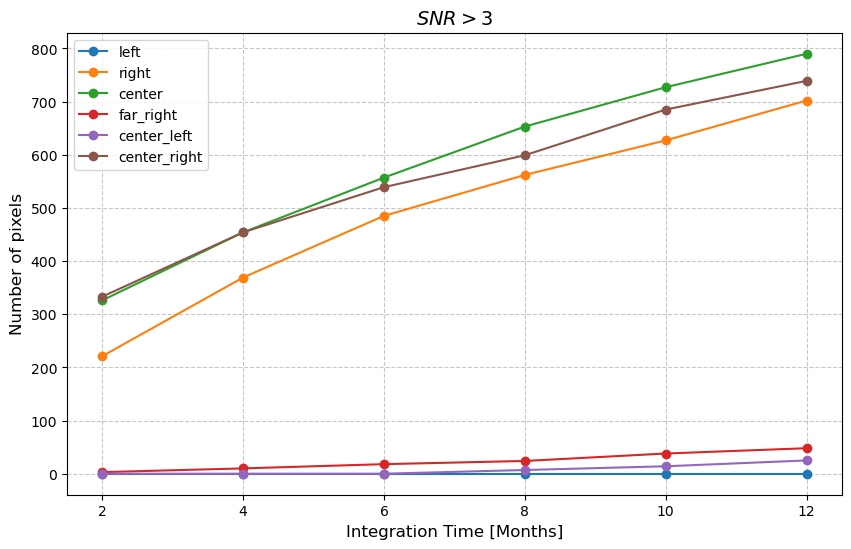

In [6]:
plt.figure(figsize=(10, 6))
months = [2, 4, 6, 8, 10, 12]
for name, r in regions.items():
    plt.plot(months, r['n_pix'][3], marker='o', label=name)

# Formattazione del grafico scientifico
plt.title('$SNR > 3$', fontsize=14)
plt.xlabel('Integration Time [Months]', fontsize=12)
plt.ylabel('Number of pixels', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(frameon=True)

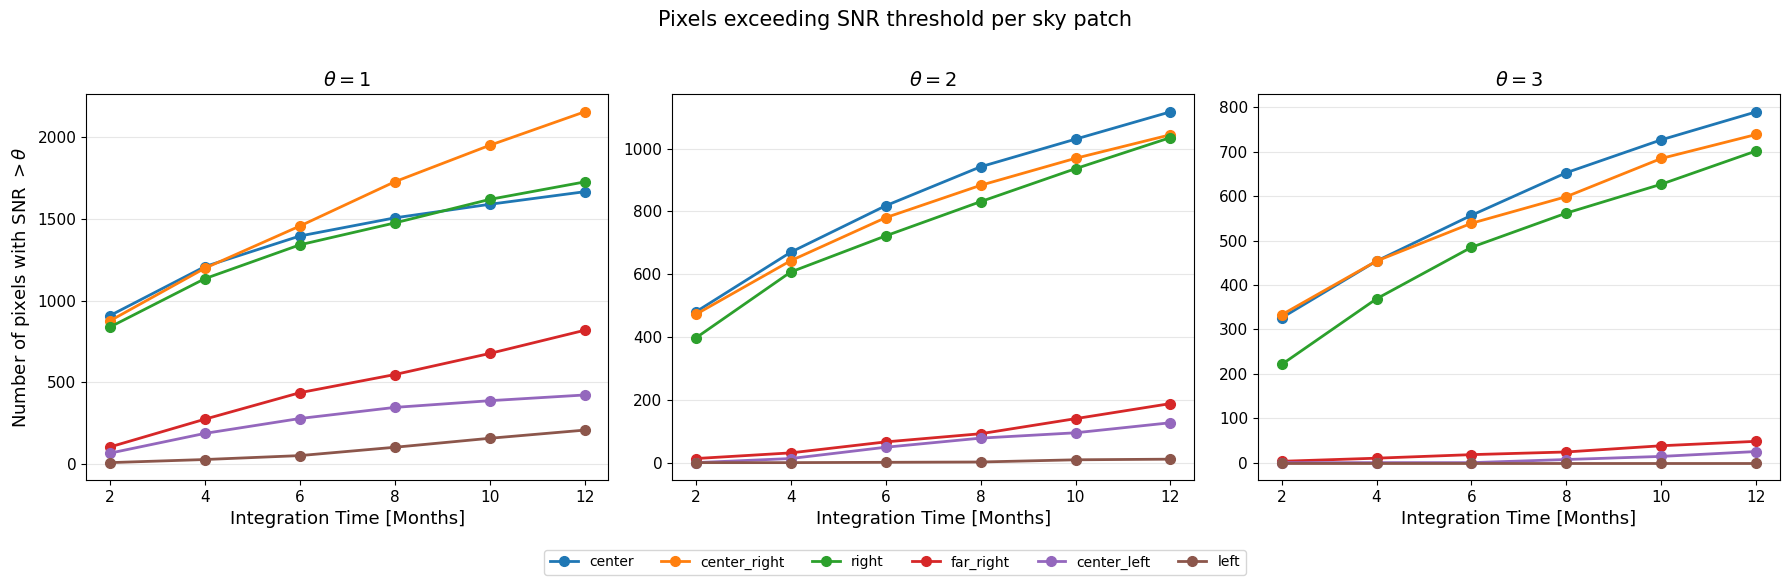

In [ ]:
colors = {
    "center":       "#1f77b4",
    "center_right": "#ff7f0e",
    "right":        "#2ca02c",
    "far_right":    "#d62728",
    "center_left":  "#9467bd",
    "left":         "#8c564b",
}

months = [2, 4, 6, 8, 10, 12]
thresholds = [1, 2, 3]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=False)

legend_order = sorted(regions.keys(),
                      key=lambda name: regions[name]['n_pix'][3][-1],
                      reverse=True)

fig.suptitle("Pixels exceeding SNR threshold per sky patch",
             fontsize=15, y=1.02)

for ax, thr in zip(axes, thresholds):
    for name in legend_order:
        r = regions[name]
        ax.plot(months, r['n_pix'][thr], marker='o', ms=7, lw=2,
                color=colors[name], label=name)

    ax.set_xlabel("Integration Time [Months]", fontsize=13)
    ax.set_xticks(months)
    ax.set_title(rf"$\theta = {thr}$", fontsize=14)
    ax.tick_params(labelsize=11)
    ax.grid(axis='y', alpha=0.3)

axes[0].set_ylabel(r"Number of pixels with SNR $> \theta$", fontsize=13)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=6,
           fontsize=10, frameon=True, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("/home/mattia/tesi/tesi/figures/snr_thresholds.pdf", bbox_inches="tight")

## Dust + CMB map with candidate sky regions

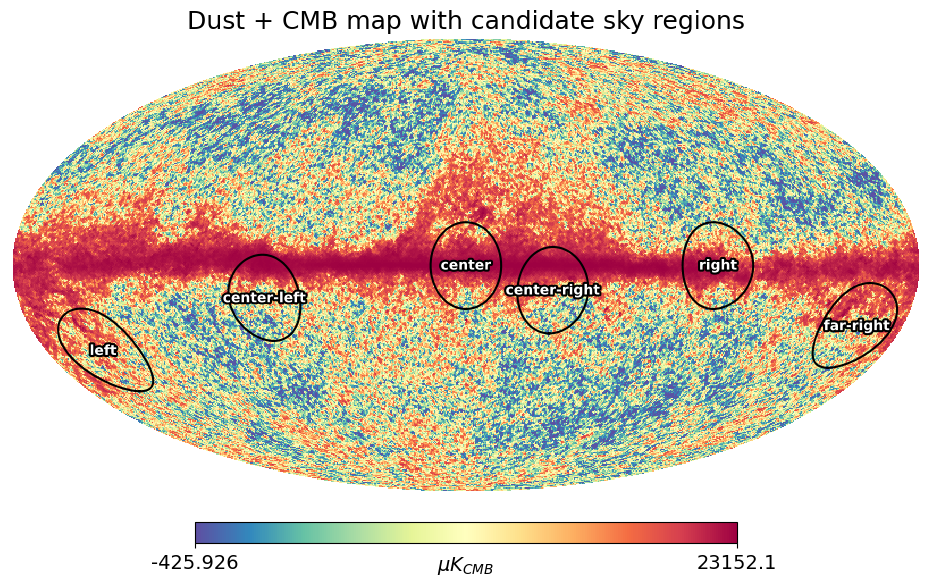

In [ ]:
import pysm3
from pysm3 import units as u
from pysm3 import bandpass_unit_conversion
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

# ── Sky map generation ──
NSIDE = 128
sky_config = {'dust': 'd1', 'cmb': 'c1'}
sky_obj = pysm3.Sky(nside=NSIDE, preset_strings=[sky_config['dust'], sky_config['cmb']])

N_SAMPLE_BAND = 100
fmin, fmax = 130, 170
freqs = np.linspace(fmin, fmax, N_SAMPLE_BAND)
weights_flat = np.ones(N_SAMPLE_BAND)

input_sky_maps = (
    sky_obj.get_emission(freqs * u.GHz, weights_flat)
    * bandpass_unit_conversion(freqs * u.GHz, weights_flat, u.uK_CMB)
)

# Stokes I map (index 0)
dust_I = np.array(input_sky_maps[0])

# ── Patch definitions (Galactic l, b in degrees) ──
patches_coordinates = {
    "left":         [155.41,  -27.88],
    "center-left":  [80.83,   -10.52],
    "center":       [0.0,       0.0],
    "right":        [260.0,     0.0],
    "center-right": [-34.67,   -8.02],
    "far-right":    [-160.9,  -19.62],
}
PATCH_RADIUS_DEG = 14.0

# ── Build combined mask for all patches ──
npix = hp.nside2npix(NSIDE)
mask = np.zeros(npix, dtype=bool)

for name, (glon, glat) in patches_coordinates.items():
    # Galactic (l, b) -> HEALPix (theta, phi)
    theta = np.radians(90.0 - glat)   # colatitude
    phi = np.radians(glon % 360.0)    # longitude in [0, 360)
    center_vec = hp.ang2vec(theta, phi)
    ipix_disc = hp.query_disc(NSIDE, center_vec, np.radians(PATCH_RADIUS_DEG))
    mask[ipix_disc] = True

# ── Create overlay map: full sky faded + patches at full intensity ──
# Background: fade the map
bg_map = dust_I.copy()
patch_map = dust_I.copy()

# Set pixels outside patches to UNSEEN so they won't be drawn in overlay
patch_map[~mask] = hp.UNSEEN

# ── Plot ──
fig = plt.figure(figsize=(14, 7))

# Plot full-sky background (faded)
hp.mollview(
    bg_map,
    title="Dust + CMB map with candidate sky regions",
    unit=r"$\mu K_{CMB}$",
    cmap="Spectral_r",
    norm='hist',
    #min=-500,
    #max=300,
    hold=True,
    fig=fig,
)

plt.title("Dust + CMB map with candidate sky regions", fontsize=18)
cb = fig.get_axes()[-1] 
cb.tick_params(labelsize=14)

# Draw circles around each patch
for name, (glon, glat) in patches_coordinates.items():
    theta_center = np.radians(90.0 - glat)
    phi_center = np.radians(glon % 360.0)

    # Generate circle points
    n_pts = 200
    angles = np.linspace(0, 2 * np.pi, n_pts)
    radius = np.radians(PATCH_RADIUS_DEG)

    # Points on a circle around the North Pole, then rotate to patch center
    circle_theta = np.full(n_pts, radius)
    circle_phi = angles

    # Convert to Cartesian
    x = np.sin(circle_theta) * np.cos(circle_phi)
    y = np.sin(circle_theta) * np.sin(circle_phi)
    z = np.cos(circle_theta)

    # Rotation: first around y-axis by theta_center, then around z-axis by phi_center
    # R_z(phi) . R_y(theta) . vec
    cos_t, sin_t = np.cos(theta_center), np.sin(theta_center)
    cos_p, sin_p = np.cos(phi_center), np.sin(phi_center)

    # R_y(theta_center)
    x1 = cos_t * x + sin_t * z
    y1 = y
    z1 = -sin_t * x + cos_t * z

    # R_z(phi_center)
    x2 = cos_p * x1 - sin_p * y1
    y2 = sin_p * x1 + cos_p * y1
    z2 = z1

    # Back to theta, phi
    theta_pts = np.arccos(np.clip(z2, -1, 1))
    phi_pts = np.arctan2(y2, x2)

    hp.projplot(theta_pts, phi_pts, color="black", lw=1.5, linestyle="-")

    # Add label at center
    import matplotlib.patheffects as pe

    hp.projtext(theta_center, phi_center, name, color="white",
            fontsize=10, ha="center", va="center", weight="bold",
            path_effects=[pe.withStroke(linewidth=3, foreground="black")])
    
#plt.savefig("/home/mattia/tesi/tesi/figures/selected_patches.pdf", bbox_inches="tight")


## 12 months SNR comparsion

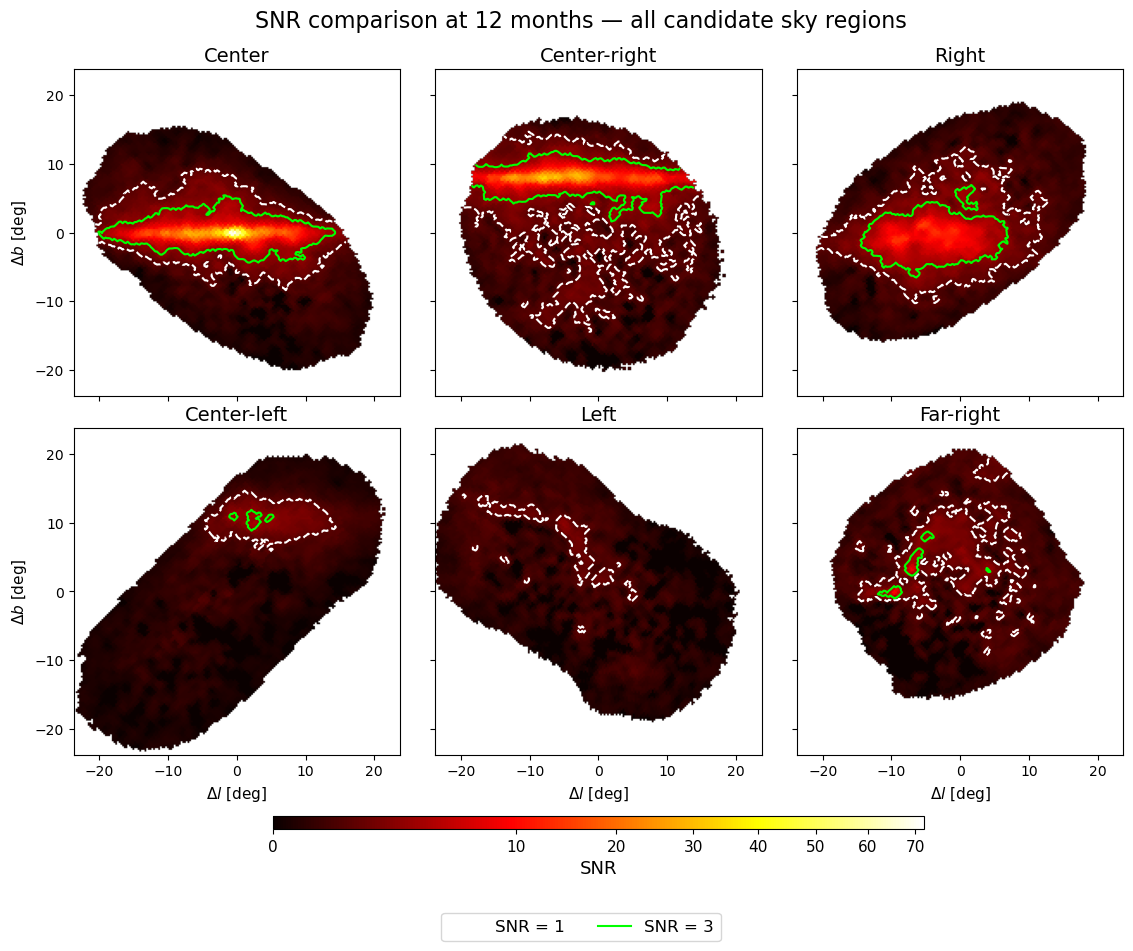

In [ ]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

save_dir = "/home/mattia/tesi/data/snr_maps/"


regions_info = [
    ("Center",       "center",       [0.0,      0.0]),
    ("Center-right", "center_right", [-34.67,  -8.02]),
    ("Right",        "right",        [260.0,    0.0]),
    ("Center-left",  "center_left",  [80.83,  -10.52]),
    ("Left",         "left",         [155.41, -27.88]),
    ("Far-right",    "far_right",    [-160.9, -19.62]),
]

snr_maps = {}
for name, suffix, cen in regions_info:
    snr = np.load(f"{save_dir}snr_{suffix}_12m.npy")
    seen = np.load(f"{save_dir}seenpix_{suffix}_12m.npy")
    snr[~seen] = hp.UNSEEN
    snr_maps[name] = {"snr": snr, "center": cen}

reso = 15
xsize = 200
fov = xsize * reso / 60.0
extent = [-fov/2, fov/2, -fov/2, fov/2]
margin = fov / 2 * 0.95

snr_levels = [1, 3]
level_colors = ["white", "lime"]
level_styles = ["--", "-"]

projected = []
for name, suffix, cen in regions_info:
    proj = hp.gnomview(snr_maps[name]["snr"], rot=cen, reso=reso, xsize=xsize,
                       return_projected_map=True, no_plot=True)
    projected.append(np.ma.masked_equal(proj, hp.UNSEEN))

vmax = max(p.max() for p in projected)

fig, axes = plt.subplots(2, 3, figsize=(14, 10),
                         gridspec_kw={"hspace": 0.1, "wspace": 0.})

from matplotlib.colors import PowerNorm
norm = PowerNorm(gamma=0.5, vmin=0, vmax=vmax)

for idx, (ax, (name, _, cen), proj) in enumerate(
        zip(axes.flat, regions_info, projected)):

    im = ax.imshow(proj, origin="lower", cmap="hot", norm=norm, extent=extent)
    ax.contour(proj, levels=snr_levels, colors=level_colors,
               linewidths=1.5, linestyles=level_styles,
               extent=extent, origin="lower")

    ax.set_title(name, fontsize=14)
    ax.set_xlim(-margin, margin)
    ax.set_ylim(-margin, margin)
    ax.tick_params(labelsize=10)

    if idx % 3 == 0:
        ax.set_ylabel(r"$\Delta b$ [deg]", fontsize=11)
    else:
        ax.set_yticklabels([])
    if idx >= 3:
        ax.set_xlabel(r"$\Delta l$ [deg]", fontsize=11)
    else:
        ax.set_xticklabels([])

cbar = fig.colorbar(im, ax=axes, orientation="horizontal",
                    fraction=0.03, pad=0.08, aspect=50, shrink=0.6)
cbar.set_label("SNR", fontsize=13)
cbar.ax.tick_params(labelsize=11)

legend_handles = [Line2D([0], [0], color=c, ls=ls, lw=1.5,
                         label=rf"SNR = {l}")
                  for l, c, ls in zip(snr_levels, level_colors, level_styles)]
fig.legend(handles=legend_handles, loc="lower center", ncol=2,
           fontsize=12, frameon=True, bbox_to_anchor=(0.5, 0))

fig.suptitle("SNR comparison at 12 months — all candidate sky regions",
             fontsize=16, y=0.94)

#plt.savefig("/home/mattia/tesi/tesi/figures/snr_comparison_12months.pdf", bbox_inches="tight")

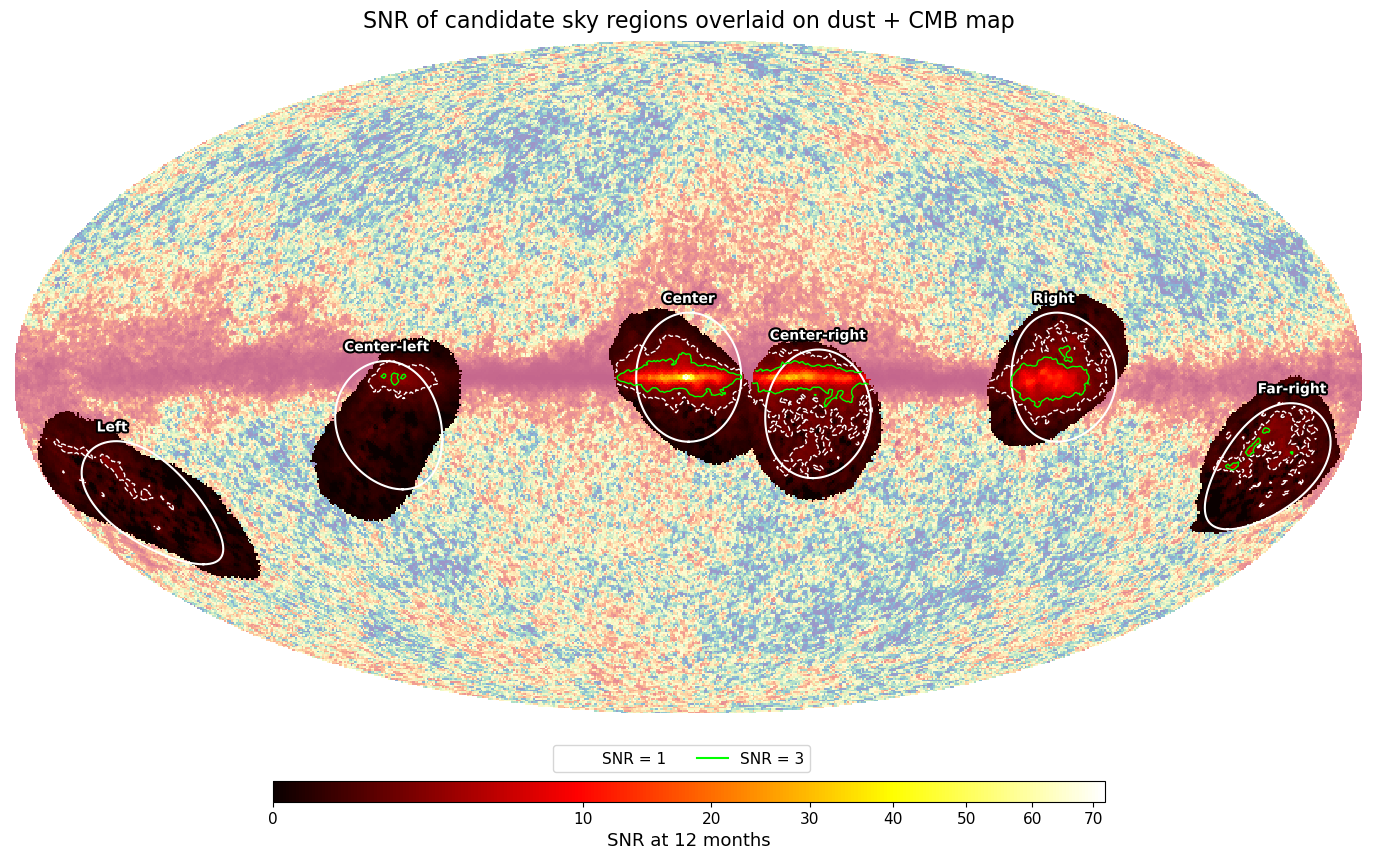

In [ ]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.colors import PowerNorm

NSIDE = 128
npix = hp.nside2npix(NSIDE)

save_dir = "/home/mattia/tesi/data/snr_maps/"

regions_info = [
    ("Center",       "center",       [0.0,      0.0]),
    ("Center-right", "center_right", [-34.67,  -8.02]),
    ("Right",        "right",        [260.0,    0.0]),
    ("Center-left",  "center_left",  [80.83,  -10.52]),
    ("Left",         "left",         [155.41, -27.88]),
    ("Far-right",    "far_right",    [-160.9, -19.62]),
]

composite_snr = np.full(npix, hp.UNSEEN)

for name, suffix, cen in regions_info:
    snr = np.load(f"{save_dir}snr_{suffix}_12m.npy")
    seen = np.load(f"{save_dir}seenpix_{suffix}_12m.npy")

    if hp.npix2nside(len(snr)) != NSIDE:
        snr = hp.ud_grade(snr, NSIDE)
        seen = hp.ud_grade(seen.astype(float), NSIDE) > 0.5

    composite_snr[seen] = snr[seen]

vmax_snr = composite_snr[composite_snr != hp.UNSEEN].max()

composite_snr_clipped = composite_snr.copy()
mask_valid = composite_snr_clipped != hp.UNSEEN
composite_snr_clipped[mask_valid] = np.clip(composite_snr_clipped[mask_valid], 0, None)
from matplotlib.colors import PowerNorm
norm = PowerNorm(gamma=0.5, vmin=0, vmax=vmax_snr)

# ── Plot ──
fig = plt.figure(figsize=(14, 8))

hp.mollview(
    bg_map,
    cmap="Spectral_r",
    norm="hist",
    cbar=False,
    title="",
    fig=fig,
    notext=True,
    sub=111,
)

ax = plt.gca()
for img in ax.get_images():
    img.set_alpha(0.6)

import copy

cmap_snr = copy.copy(plt.cm.hot)
cmap_snr.set_bad(color=(0, 0, 0, 0))  

hp.mollview(
    composite_snr_clipped,
    cmap=cmap_snr,
    min=0,
    max=vmax_snr,
    norm=norm,
    reuse_axes=True,
    cbar=False,
    title="",
    unit="SNR at 12 months",
    notext=True,
    badcolor="none",  
    bgcolor="none",
)

PATCH_RADIUS_DEG = 14.0
patches_coordinates = {name: cen for name, _, cen in regions_info}

for name, (glon, glat) in patches_coordinates.items():
    theta_center = np.radians(90.0 - glat)
    phi_center = np.radians(glon % 360.0)

    n_pts = 200
    angles = np.linspace(0, 2 * np.pi, n_pts)
    circle_theta = np.full(n_pts, np.radians(PATCH_RADIUS_DEG))
    circle_phi = angles

    x = np.sin(circle_theta) * np.cos(circle_phi)
    y = np.sin(circle_theta) * np.sin(circle_phi)
    z = np.cos(circle_theta)

    cos_t, sin_t = np.cos(theta_center), np.sin(theta_center)
    cos_p, sin_p = np.cos(phi_center), np.sin(phi_center)

    x1 = cos_t * x + sin_t * z
    y1 = y
    z1 = -sin_t * x + cos_t * z

    x2 = cos_p * x1 - sin_p * y1
    y2 = sin_p * x1 + cos_p * y1
    z2 = z1

    theta_pts = np.arccos(np.clip(z2, -1, 1))
    phi_pts = np.arctan2(y2, x2)

    label_offset = PATCH_RADIUS_DEG + 3 
    theta_label = np.radians(90.0 - (glat + label_offset))

    hp.projplot(theta_pts, phi_pts, color="white", lw=1.5, linestyle="-")
    hp.projtext(theta_label, phi_center, name, color="white",
                fontsize=10, ha="center", va="center", weight="bold",
                path_effects=[pe.withStroke(linewidth=3, foreground="black")])

ax_curr = plt.gca()
img_snr = ax_curr.get_images()[-1] 
snr_rendered = img_snr.get_array()
ext = img_snr.get_extent()

ax_curr.contour(snr_rendered, levels=[1, 3],
                colors=["white", "lime"],
                linewidths=1,
                linestyles=["--", "-"],
                extent=ext,
                origin="lower")

from matplotlib.cm import ScalarMappable
sm = ScalarMappable(cmap=cmap_snr,
                    norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=fig.gca(), orientation="horizontal",
                    fraction=0.05, pad=0.08, aspect=40, shrink=0.6)
cbar.set_label("SNR at 12 months", fontsize=13)
cbar.ax.tick_params(labelsize=11)

plt.title("SNR of candidate sky regions overlaid on dust + CMB map",
          fontsize=16)

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color="white", ls="--", lw=1.5, label="SNR = 1"),
    Line2D([0], [0], color="lime", ls="-", lw=1.5, label="SNR = 3"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=2,
           fontsize=11, bbox_to_anchor=(0.5, 0.05))

plt.savefig("/home/mattia/tesi/tesi/figures/snr_overlay_fullsky.pdf",
            bbox_inches="tight")